# Pose Dataset Comparison and Merge

This notebook does three things:
1. Loads and compares the two pose dataset schemas.
2. Visualizes labeled samples from each dataset.
3. Merges both datasets into a unified YOLO pose dataset with a consistent keypoint order.
4. Creates sequence-aware train/val/test splits without random adjacent-frame leakage.

In [11]:
from pathlib import Path
from collections import Counter
import shutil
import random

import yaml
import cv2
import numpy as np
import matplotlib.pyplot as plt

random.seed(42)
np.random.seed(42)

ROOT = Path("..").resolve()
DATASET_A = ROOT / "dataset/pose/pose-dataset-daniel"
DATASET_B = ROOT / "dataset/pose/pose-dataset-joaquin"
MERGED = ROOT / "dataset/pose/pose-dataset-merged"
MERGED_SPLIT = ROOT / "dataset/pose/pose-dataset-merged-split"

print(f"Project root: {ROOT}")
print(f"Dataset A: {DATASET_A}")
print(f"Dataset B: {DATASET_B}")
print(f"Merged output: {MERGED}")
print(f"Sequence-aware output: {MERGED_SPLIT}")

Project root: C:\dev\poultry-vision
Dataset A: C:\dev\poultry-vision\dataset\pose\pose-dataset-daniel
Dataset B: C:\dev\poultry-vision\dataset\pose\pose-dataset-joaquin
Merged output: C:\dev\poultry-vision\dataset\pose\pose-dataset-merged


In [12]:
def load_yaml(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return yaml.safe_load(f)


def schema_snapshot(cfg: dict):
    names = cfg["kpt_names"][0]
    return {
        "kpt_shape": cfg.get("kpt_shape"),
        "flip_idx": cfg.get("flip_idx"),
        "class_names": cfg.get("names"),
        "kpt_names": names,
    }


a_cfg = load_yaml(DATASET_A / "data.yaml")
b_cfg = load_yaml(DATASET_B / "data.yaml")

a_schema = schema_snapshot(a_cfg)
b_schema = schema_snapshot(b_cfg)

print("Dataset A keypoints:")
for i, name in enumerate(a_schema["kpt_names"]):
    print(f"  {i:>2}: {name}")

print("\nDataset B keypoints:")
for i, name in enumerate(b_schema["kpt_names"]):
    print(f"  {i:>2}: {name}")

print("\nSchema checks")
print(f"  Same kpt_shape: {a_schema['kpt_shape'] == b_schema['kpt_shape']}")
print(f"  Same class map: {a_schema['class_names'] == b_schema['class_names']}")
print(f"  Same keypoint order: {a_schema['kpt_names'] == b_schema['kpt_names']}")

Dataset A keypoints:
   0: tail_base
   1: tail_tip
   2: left_hock
   3: right_hock
   4: left_foot
   5: right_foot
   6: neck_back
   7: middle_back
   8: comb
   9: beak

Dataset B keypoints:
   0: beak
   1: crown
   2: back_neck
   3: middle_back
   4: tail_base
   5: tail_tip
   6: left_hock
   7: left_foot
   8: right_hock
   9: right_foot

Schema checks
  Same kpt_shape: True
  Same class map: True
  Same keypoint order: False


## Visualize Labeled Samples

The next cells draw bounding boxes and visible keypoints directly from YOLO pose labels for both datasets.

In [13]:
def find_image_for_label(label_path: Path) -> Path | None:
    stem = label_path.stem
    image_dir = label_path.parent.parent.parent / "images" / label_path.parent.name
    for ext in (".jpg", ".jpeg", ".png", ".bmp", ".webp"):
        candidate = image_dir / f"{stem}{ext}"
        if candidate.exists():
            return candidate
    return None


def parse_pose_line(line: str, n_kpts: int = 10):
    vals = [float(x) for x in line.strip().split()]
    if len(vals) < 5 + 3 * n_kpts:
        return None
    cls_id = int(vals[0])
    box = vals[1:5]
    kpt_vals = vals[5:5 + 3 * n_kpts]
    kpts = np.array(kpt_vals, dtype=np.float32).reshape(n_kpts, 3)
    return cls_id, box, kpts


def draw_pose_annotations(image_bgr: np.ndarray, label_path: Path, keypoint_names: list[str]):
    h, w = image_bgr.shape[:2]
    out = image_bgr.copy()

    # Keep visualization size consistent across datasets so keypoints remain visible.
    max_dim = 1400
    if max(h, w) > max_dim:
        scale = max_dim / max(h, w)
        out = cv2.resize(out, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_AREA)
        h, w = out.shape[:2]

    draw_scale = max(h, w) / 900.0
    box_thickness = max(2, int(round(2 * draw_scale)))
    point_radius = max(5, int(round(6 * draw_scale)))
    text_scale = max(0.5, 0.6 * draw_scale)
    text_thickness = max(1, int(round(1.5 * draw_scale)))

    with open(label_path, "r", encoding="utf-8") as f:
        lines = [ln.strip() for ln in f.readlines() if ln.strip()]

    for line in lines:
        parsed = parse_pose_line(line, n_kpts=len(keypoint_names))
        if parsed is None:
            continue

        _, (cx, cy, bw, bh), kpts = parsed

        x1 = int((cx - bw / 2) * w)
        y1 = int((cy - bh / 2) * h)
        x2 = int((cx + bw / 2) * w)
        y2 = int((cy + bh / 2) * h)
        cv2.rectangle(out, (x1, y1), (x2, y2), (255, 200, 0), box_thickness)

        for idx, (x, y, v) in enumerate(kpts):
            if v <= 0:
                continue

            px = int(x * w)
            py = int(y * h)

            # Two-layer marker to stay visible on bright feathers and cluttered backgrounds.
            cv2.circle(out, (px, py), point_radius + 2, (0, 0, 0), -1)
            color = (0, 230, 255) if v < 2 else (0, 255, 0)
            cv2.circle(out, (px, py), point_radius, color, -1)

            cv2.putText(
                out,
                str(idx),
                (px + point_radius + 2, py - point_radius - 2),
                cv2.FONT_HERSHEY_SIMPLEX,
                text_scale,
                (255, 255, 255),
                text_thickness + 1,
                cv2.LINE_AA,
            )
            cv2.putText(
                out,
                str(idx),
                (px + point_radius + 2, py - point_radius - 2),
                cv2.FONT_HERSHEY_SIMPLEX,
                text_scale,
                (20, 20, 255),
                text_thickness,
                cv2.LINE_AA,
            )

    return out


def sample_label_files(dataset_root: Path, split: str, n: int = 4):
    label_dir = dataset_root / "labels" / split
    files = sorted(label_dir.glob("*.txt"))
    if not files:
        return []
    n = min(n, len(files))
    return random.sample(files, n)


def show_samples(dataset_root: Path, keypoint_names: list[str], title: str, split: str = "train", n: int = 4):
    labels = sample_label_files(dataset_root, split=split, n=n)
    if not labels:
        print(f"No labels found: {dataset_root / 'labels' / split}")
        return

    fig, axes = plt.subplots(1, len(labels), figsize=(5 * len(labels), 5))
    if len(labels) == 1:
        axes = [axes]

    for ax, lbl in zip(axes, labels):
        img_path = find_image_for_label(lbl)
        if img_path is None:
            ax.set_title(f"Missing image\n{lbl.name}")
            ax.axis("off")
            continue

        img = cv2.imread(str(img_path))
        if img is None:
            ax.set_title(f"Unreadable image\n{img_path.name}")
            ax.axis("off")
            continue

        drawn = draw_pose_annotations(img, lbl, keypoint_names)
        ax.imshow(cv2.cvtColor(drawn, cv2.COLOR_BGR2RGB))
        ax.set_title(img_path.name)
        ax.axis("off")

    fig.suptitle(f"{title} ({split})", fontsize=14)
    plt.tight_layout()
    plt.show()

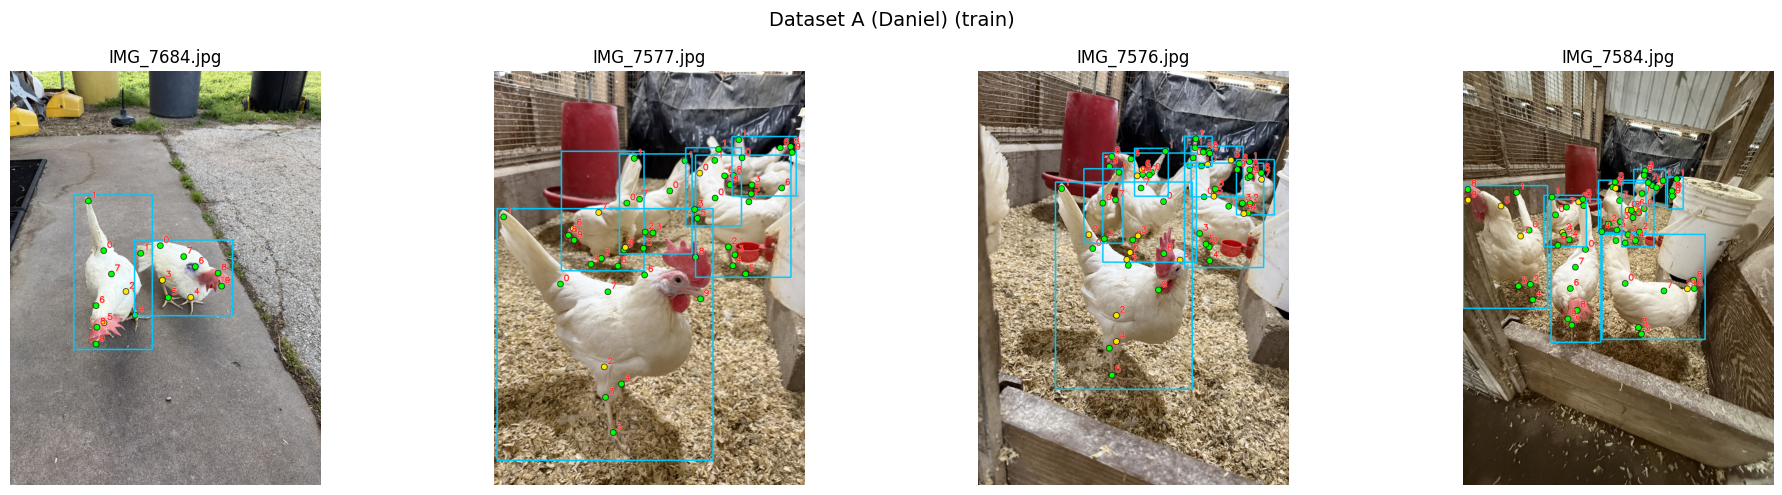

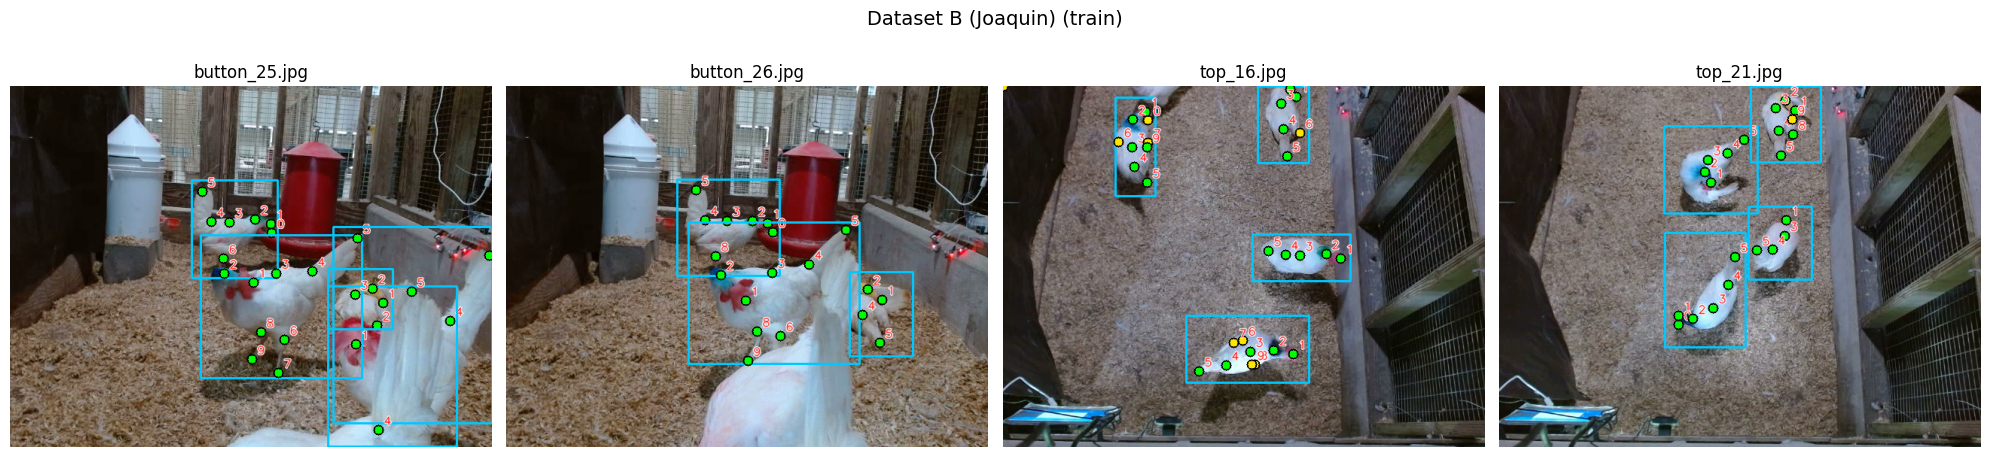

In [10]:
show_samples(DATASET_A, a_schema["kpt_names"], title="Dataset A (Daniel)", split="train", n=4)
show_samples(DATASET_B, b_schema["kpt_names"], title="Dataset B (Joaquin)", split="train", n=4)

## Merge Datasets With Unified Keypoint Order

We will use Dataset A keypoint order as canonical:
- `tail_base, tail_tip, left_hock, right_hock, left_foot, right_foot, neck_back, middle_back, comb, beak`

Dataset B keypoints are remapped into this canonical order during merge.
The merge keeps train/val splits and prefixes filenames (`daniel_`, `joaquin_`) to avoid collisions.

In [14]:
canonical_kpts = a_schema["kpt_names"]

# Dataset B semantic aliases mapped onto canonical names.
b_alias_to_canonical = {
    "crown": "comb",
    "back_neck": "neck_back",
}


def canonicalize_name(name: str) -> str:
    return b_alias_to_canonical.get(name, name)


def build_index_mapping(source_names: list[str], target_names: list[str]):
    target_index = {name: i for i, name in enumerate(target_names)}
    mapping = {}
    for i, name in enumerate(source_names):
        cname = canonicalize_name(name)
        if cname not in target_index:
            raise ValueError(f"Cannot map keypoint '{name}' -> '{cname}' to canonical schema")
        mapping[i] = target_index[cname]
    return mapping


a_to_canonical = build_index_mapping(a_schema["kpt_names"], canonical_kpts)
b_to_canonical = build_index_mapping(b_schema["kpt_names"], canonical_kpts)

print("A -> canonical index map:", a_to_canonical)
print("B -> canonical index map:", b_to_canonical)


def remap_kpts(kpts: np.ndarray, idx_map: dict[int, int], n_kpts_out: int):
    out = np.zeros((n_kpts_out, 3), dtype=np.float32)
    for src_i, dst_i in idx_map.items():
        out[dst_i] = kpts[src_i]
    return out


def remap_label_line(line: str, idx_map: dict[int, int], n_kpts_in: int, n_kpts_out: int):
    vals = line.strip().split()
    if not vals:
        return None

    floats = [float(v) for v in vals]
    if len(floats) < 5 + 3 * n_kpts_in:
        return None

    cls_id = int(floats[0])
    box = floats[1:5]
    kpts_in = np.array(floats[5:5 + 3 * n_kpts_in], dtype=np.float32).reshape(n_kpts_in, 3)
    kpts_out = remap_kpts(kpts_in, idx_map, n_kpts_out=n_kpts_out)

    out_vals = [str(cls_id)] + [f"{v:.6f}" for v in box] + [f"{v:.6f}" for v in kpts_out.reshape(-1)]
    return " ".join(out_vals)


def copy_and_remap_split(src_root: Path, prefix: str, idx_map: dict[int, int], source_names: list[str], split: str):
    src_img_dir = src_root / "images" / split
    src_lbl_dir = src_root / "labels" / split

    dst_img_dir = MERGED / "images" / split
    dst_lbl_dir = MERGED / "labels" / split
    dst_img_dir.mkdir(parents=True, exist_ok=True)
    dst_lbl_dir.mkdir(parents=True, exist_ok=True)

    img_count = 0
    obj_count = 0

    label_files = sorted(src_lbl_dir.glob("*.txt"))
    for lbl in label_files:
        stem = lbl.stem
        out_stem = f"{prefix}_{stem}"

        image_path = find_image_for_label(lbl)
        if image_path is not None and image_path.exists():
            out_img = dst_img_dir / f"{out_stem}{image_path.suffix.lower()}"
            shutil.copy2(image_path, out_img)
            img_count += 1

        out_label = dst_lbl_dir / f"{out_stem}.txt"
        out_lines = []
        with open(lbl, "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                remapped = remap_label_line(
                    line,
                    idx_map=idx_map,
                    n_kpts_in=len(source_names),
                    n_kpts_out=len(canonical_kpts),
                )
                if remapped is not None:
                    out_lines.append(remapped)
                    obj_count += 1

        with open(out_label, "w", encoding="utf-8") as wf:
            if out_lines:
                wf.write("\n".join(out_lines) + "\n")

    return {
        "split": split,
        "images": img_count,
        "labels": len(label_files),
        "objects": obj_count,
    }

A -> canonical index map: {0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8, 9: 9}
B -> canonical index map: {0: 9, 1: 8, 2: 6, 3: 7, 4: 0, 5: 1, 6: 2, 7: 4, 8: 3, 9: 5}


In [18]:
if MERGED.exists():
    shutil.rmtree(MERGED)

stats = []
for split in ("train", "val"):
    stats.append(copy_and_remap_split(DATASET_A, "daniel", a_to_canonical, a_schema["kpt_names"], split))
    stats.append(copy_and_remap_split(DATASET_B, "joaquin", b_to_canonical, b_schema["kpt_names"], split))

print("Merge stats:")
for s in stats:
    print(
        f"  split={s['split']:<5} images={s['images']:<4} labels={s['labels']:<4} objects={s['objects']:<5}"
    )

Merge stats:
  split=train images=79   labels=79   objects=174  
  split=train images=43   labels=43   objects=155  
  split=val   images=20   labels=20   objects=81   
  split=val   images=11   labels=11   objects=50   


In [19]:
merged_yaml = {
    "path": str(MERGED.resolve()),
    "train": "images/train",
    "val": "images/val",
    "kpt_shape": [len(canonical_kpts), 3],
    "flip_idx": a_schema["flip_idx"],
    "names": {0: "hen"},
    "kpt_names": {0: canonical_kpts},
}

with open(MERGED / "data.yaml", "w", encoding="utf-8") as f:
    yaml.safe_dump(merged_yaml, f, sort_keys=False)

print("Wrote merged data.yaml:")
print(MERGED / "data.yaml")
print("\nCanonical keypoint order:")
for i, k in enumerate(canonical_kpts):
    print(f"  {i:>2}: {k}")

Wrote merged data.yaml:
C:\dev\poultry-vision\dataset\pose\pose-dataset-merged\data.yaml

Canonical keypoint order:
   0: tail_base
   1: tail_tip
   2: left_hock
   3: right_hock
   4: left_foot
   5: right_foot
   6: neck_back
   7: middle_back
   8: comb
   9: beak


Merged train: images=122, labels=122, objects=329
Merged val: images=31, labels=31, objects=131


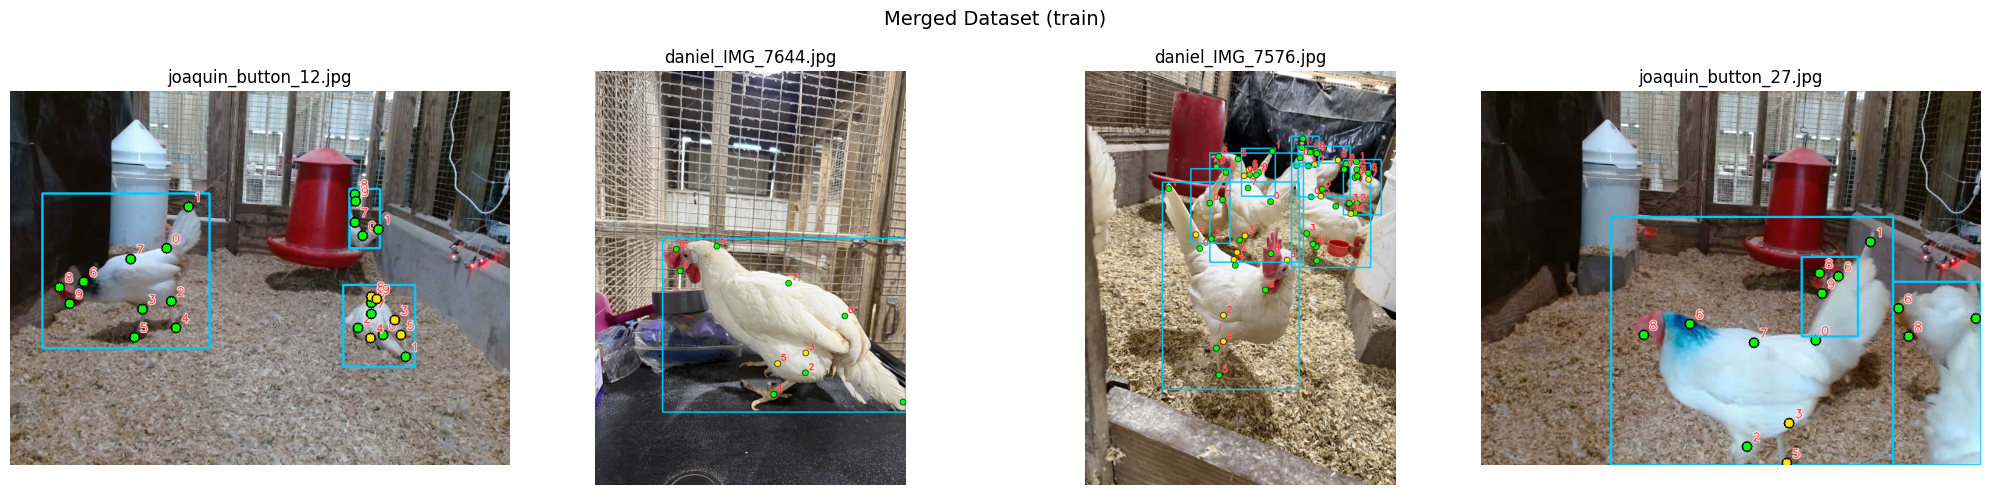

In [20]:
def count_labels_and_objects(label_dir: Path):
    n_files = 0
    n_objects = 0
    for p in label_dir.glob("*.txt"):
        n_files += 1
        with open(p, "r", encoding="utf-8") as f:
            n_objects += sum(1 for ln in f if ln.strip())
    return n_files, n_objects


for split in ("train", "val"):
    lbl_dir = MERGED / "labels" / split
    img_dir = MERGED / "images" / split
    n_lbl, n_obj = count_labels_and_objects(lbl_dir)
    n_img = len([p for p in img_dir.glob("*") if p.is_file()])
    print(f"Merged {split}: images={n_img}, labels={n_lbl}, objects={n_obj}")

show_samples(MERGED, canonical_kpts, title="Merged Dataset", split="train", n=4)

## Create Sequence-aware Train/Val/Test Splits

Frames from the same recording/view are sorted and assigned as contiguous 70/15/15 blocks. This is stricter than a random image split because neighboring video frames cannot land in different splits.

In [ ]:
import subprocess
import sys

subprocess.check_call([
    sys.executable,
    str(ROOT / "scripts/split_pose_dataset.py"),
    str(MERGED),
    str(MERGED_SPLIT),
])
subprocess.check_call([
    sys.executable,
    str(ROOT / "scripts/validate_pose_dataset.py"),
    str(MERGED_SPLIT / "data.yaml"),
])

## Result

You now have a unified pose dataset at `dataset/pose/pose-dataset-merged` with:
- merged train/val images and labels,
- canonical keypoint order,
- generated `data.yaml` ready for YOLO pose training.

The recommended experiment dataset is `dataset/pose/pose-dataset-merged-split`, which adds an untouched test split and a saved `split_manifest.json`.